# Импорт библиотек

In [1]:
from IPython.display import clear_output
!pip install gdown
!pip install optuna
!pip install catboost
!pip install pytorch-tabnet
!pip install -U imbalanced-learn
clear_output()

In [2]:
import catboost
import itertools 
import imblearn
import lightgbm
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import scipy
import seaborn as sns
import sklearn
import sklearn.datasets
import xgboost

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV, cross_validate, cross_val_score
from sklearn.metrics import mean_squared_error, average_precision_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import average_precision_score, matthews_corrcoef
from pytorch_tabnet.tab_model import  TabNetRegressor

# Задание 1. Bias-variance trade-off

Продемонстрируйте bias-variance trade-off для `DecisionTreeRegressor` при изменении глубины дерева. Постройте регрессионную модель функции от одной независимой переменной, представленной в ячейке ниже, используя функцию plot_regression_predictions (можете модифицировать).

Продемонстрировать - показать как строится решающее дерево, в зависимости от глубины дерева.

In [3]:
np.random.seed(42)
m = 200
X = np.random.rand(m, 1) * 3 - 1
y = 4 * (X - 0.5) ** 3
y = y + np.random.randn(m, 1) / 10

In [4]:
def plot_regression_predictions(tree_reg, X, y, axes=[0, 1, -1, 1], ylabel="$y$"):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$", fontsize=18)
    if ylabel:
        plt.ylabel(ylabel, fontsize=18, rotation=0)
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

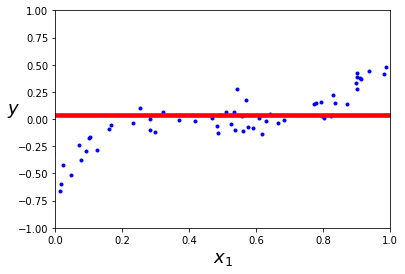

In [5]:
model = DecisionTreeRegressor(max_depth = 4)
model.fit(X, y)
plot_regression_predictions(model, X, y)

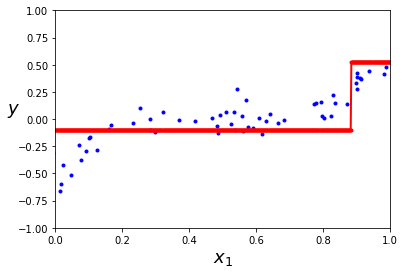

In [6]:
model = DecisionTreeRegressor(max_depth = 5)
model.fit(X, y)
plot_regression_predictions(model, X, y)

Первое отклонение от просто прямой

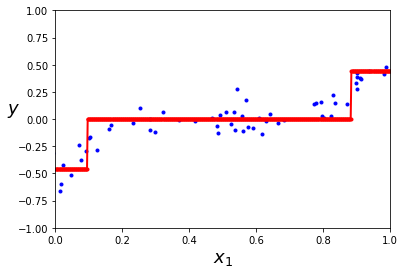

In [7]:
model = DecisionTreeRegressor(max_depth = 6)
model.fit(X, y)
plot_regression_predictions(model, X, y)

Относительно неплохо, хотя бы примерно похоже на реальность

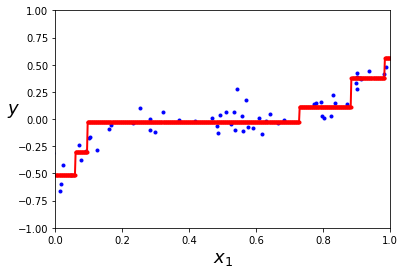

In [8]:
model = DecisionTreeRegressor(max_depth = 7)
model.fit(X, y)
plot_regression_predictions(model, X, y)

Похоже на самый хороший результат и даже напоминает кубическую параболу, при нужной доли фантазии

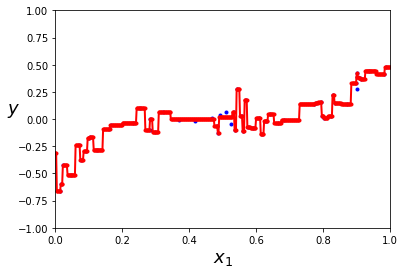

In [9]:
model = DecisionTreeRegressor(max_depth = 15)
model.fit(X, y)
plot_regression_predictions(model, X, y)

Тут, видимо, уже переобучение, т.к. похоже что фит и шум учел. При дальнейшем увеличении глубины визуально остается все также

# Задание 2. Bootstrap

В этом задании используйте датасет breast_cancer &mdash; классический датасет для задачи бинарной классификации. Обучите модели:

 - `DecisionTreeClassifier`
 -`RandomForestClassifier` 
 -`LigthGBMClassifier` 
 -`SVC` 
 -`BaggingClassifier` с базовым класификатором - SVC . 
 
Параметры моделей можете оставить по умолчанию или задать сами.

Для каждой модели посчитайте корреляцию Мэтьюса &mdash; метрику для оценки качества бинарной классификации, в частности, устойчивую к дисбалансу классов, (`sklearn.metrics.matthews_corrcoef`, подробнее почитать про его пользу можно [здесь](https://bmcgenomics.biomedcentral.com/articles/10.1186/s12864-019-6413-7)) для предсказанного ею класса и реального 

С помощью bootstrap-подхода постройте 90% доверительные интервалы для качества полученных моделей. Используйте функцию bootstrap metric из лекции.

Постройте единый boxplot для качества полученных моделей

In [10]:
breast_cancer = sklearn.datasets.load_breast_cancer()
print(breast_cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        worst/largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 0 is Mean Radi

In [11]:
X = breast_cancer.data
y = breast_cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [12]:
def bootstrap_metric(X, 
                     Y,
                     metric_fn,
                     samples_cnt = 1000,
                     random_state = 42):
    
    np.random.seed(random_state)
    b_metric = np.zeros(samples_cnt)
    for it in range(samples_cnt):
        poses = np.random.choice(X.shape[0], size=X.shape[0], replace=True)
        
        X_boot = X[poses]
        Y_boot = Y[poses]
        
        m_val = metric_fn(X_boot, Y_boot)
        b_metric[it] = m_val
    
    return b_metric


0.8683984553103156 0.940477037066757 0.9107365792759051 0.8965050191922527 0.8820040479121384


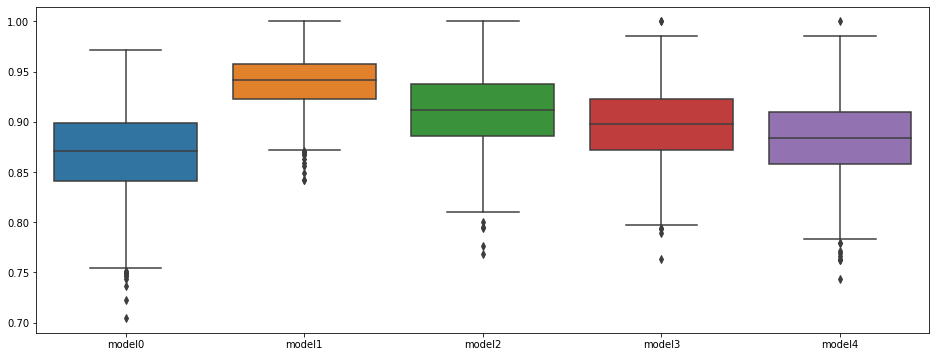

In [13]:
model0 = DecisionTreeRegressor(max_depth = 7)
model0.fit(X_train, y_train)
y_pred = model0.predict(X_test)
L0 = matthews_corrcoef(y_true=y_test, y_pred=np.round(y_pred))
metric0 = bootstrap_metric(y_test, np.round(y_pred), matthews_corrcoef)

model1 = RandomForestClassifier()
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)
L1 = matthews_corrcoef(y_true=y_test, y_pred=np.round(y_pred))
metric1 = bootstrap_metric(y_test, np.round(y_pred), matthews_corrcoef)

model2 = lightgbm.LGBMClassifier()
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)
L2 = matthews_corrcoef(y_true=y_test, y_pred=np.round(y_pred))
metric2 = bootstrap_metric(y_test, np.round(y_pred), matthews_corrcoef)

model3 = SVC()
model3.fit(X_train, y_train)
y_pred = model3.predict(X_test)
L3 = matthews_corrcoef(y_true=y_test, y_pred=np.round(y_pred))
metric3 = bootstrap_metric(y_test, np.round(y_pred), matthews_corrcoef)

model4 = BaggingClassifier(base_estimator = SVC())
model4.fit(X_train, y_train)
y_pred = model4.predict(X_test)
L4 = matthews_corrcoef(y_true=y_test, y_pred=np.round(y_pred))
metric4 = bootstrap_metric(y_test, np.round(y_pred), matthews_corrcoef)

print(L0, L1, L2, L3, L4)


plt.figure(figsize=(16,6))
sns.boxplot(y=np.concatenate([metric0, metric1, metric2, metric3, metric4]),
            x=['model0']*1000 + ["model1"] * 1000 + ['model2'] * 1000 + ['model3'] * 1000 + ['model4'] * 1000)
plt.show()

# Задание 3. Обучение и подбор параметров


Загрузим датасет с рецептами (состав блюд и дополнительные данные о них) и рейтинге рецептов.

In [14]:
!gdown --id 1gr1WaAFZphKQxzUFIxAYqiTqRJsC-mFK -O recipes.csv

Downloading...
From: https://drive.google.com/uc?id=1gr1WaAFZphKQxzUFIxAYqiTqRJsC-mFK
To: /content/recipes.csv
100% 55.3M/55.3M [00:00<00:00, 99.2MB/s]


In [15]:
recipies = pd.read_csv("recipes.csv")
print(recipies.iloc[:, 0:5].head())

                                         title  rating  calories  protein  \
0              Lentil, Apple, and Turkey Wrap    2.500     426.0     30.0   
1  Boudin Blanc Terrine with Red Onion Confit    4.375     403.0     18.0   
2                Potato and Fennel Soup Hodge    3.750     165.0      6.0   
3             Mahi-Mahi in Tomato Olive Sauce    5.000       NaN      NaN   
4                    Spinach Noodle Casserole    3.125     547.0     20.0   

    fat  
0   7.0  
1  23.0  
2   7.0  
3   NaN  
4  32.0  


In [16]:
recipies = recipies.loc[pd.isna(recipies).sum(axis=1)==0, :] # remove na
y = recipies['rating']
X = recipies.drop(["rating", "title"], axis=1)
X_train_all, X_test, y_train_all, y_test = train_test_split(X.values, y.values, train_size=0.7, random_state=1999)

Постройте модель, предсказывающую рейтинг рецепта по всем имеющимся признакам.

Выберите 2 модели &mdash; **один** случайный лес и **один** бустинг из приведенных ниже.

1. `xgboost.XGBRegressor`
2. `xgboost.XGBRFRegressor` &mdash; случайный лес от xgboost
3. `lightgbm.LGBMRegressor`
4. `lightgbm.LGBMRegressor(boosting_type="rf")` &mdash; случайный лес от lightgbm
5. `catboost.CatBoostRegressor`

Кроме этого, используйте **так же**
`TabNetRegressor`

Для первых двух моделей попытайтесь оптимизировать их параметры, чтобы получить хорошее качество 
Для TabNetRegressor попробуйте разные значения параметров `n_a` и `n_d`. Поставьте число эпох (`max_epochs`, параметр функции `fit`) равным 30 (можете при желании подбирать и этот параметр)

Сравните качество полученных моделей 

In [17]:
model_derevo = xgboost.XGBRFRegressor(max_depth = 12, n_estimators = 1500)
model_derevo.fit(X_train_all, y_train_all)
y_pred_derevo = model_derevo.predict(X_test)
qual_derevo = mean_squared_error(y_test, y_pred_derevo)
print(qual_derevo)

[17:46:23] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
1.4421459600905013


Ну это жесть, я считал для разных depth и estimators, с этими параметрами получился и правда лучший вариант, но это дико долго. Но на самом деле даже при depth = 5 отличия не сильны, т.е. quel_derevo получается 1.49... видимо estimator должен быь сильно больше 1000, но боюсь тогда не хватит и всего занятия чтобы это все посчитать. 

In [18]:
for i in range (15):
  model_xboost = xgboost.XGBRegressor(max_depth=i)
  model_xboost.fit(X_train_all, y_train_all)
  y_pred_xboost = model_xboost.predict(X_test)
  qual_xboost = mean_squared_error(y_test, y_pred_xboost)
  print(i,":", qual_xboost)

[17:59:12] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
0 : 1.723724856010517
[17:59:15] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
1 : 1.514836816045551
[17:59:23] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
2 : 1.4681974320393378
[17:59:35] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
3 : 1.44360981819829
[17:59:51] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
4 : 1.42757625224044
[18:00:11] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
5 : 1.4103356015373838
[18:00:35] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor 

Вообще немного странный результат, видно что уже при depth = 7 у нас есть некий выход на плато, но на при depth = 14 мы получили qual_xboost = 1.358. Не совсем понятно переобучение это или нет, но судя по предыдущим значениям всеже переобучение. Однако, очень радует, что это быстро относительно

In [19]:
model_tab = TabNetRegressor(n_a = 5, n_d = 10)
model_tab.fit(X_train_all, y_train_all.reshape(-1, 1), max_epochs=30)
y_pred_tab = model_tab.predict(X_test)
qual_tab = mean_squared_error(y_test, y_pred_tab)
print(qual_tab)

Device used : cpu
No early stopping will be performed, last training weights will be used.
epoch 0  | loss: 11.24594|  0:00:03s
epoch 1  | loss: 3.70836 |  0:00:06s
epoch 2  | loss: 2.18017 |  0:00:10s
epoch 3  | loss: 1.84762 |  0:00:13s
epoch 4  | loss: 1.70742 |  0:00:17s
epoch 5  | loss: 1.64781 |  0:00:20s
epoch 6  | loss: 1.62958 |  0:00:24s
epoch 7  | loss: 1.61288 |  0:00:27s
epoch 8  | loss: 1.61911 |  0:00:30s
epoch 9  | loss: 1.58349 |  0:00:34s
epoch 10 | loss: 1.59062 |  0:00:37s
epoch 11 | loss: 1.58842 |  0:00:40s
epoch 12 | loss: 1.55586 |  0:00:44s
epoch 13 | loss: 1.54231 |  0:00:47s
epoch 14 | loss: 1.53451 |  0:00:50s
epoch 15 | loss: 1.54966 |  0:00:54s
epoch 16 | loss: 1.51029 |  0:00:57s
epoch 17 | loss: 1.50963 |  0:01:01s
epoch 18 | loss: 1.48636 |  0:01:04s
epoch 19 | loss: 1.47839 |  0:01:07s
epoch 20 | loss: 1.4376  |  0:01:11s
epoch 21 | loss: 1.42784 |  0:01:14s
epoch 22 | loss: 1.37591 |  0:01:17s
epoch 23 | loss: 1.35909 |  0:01:21s
epoch 24 | loss: 1.32

Вообще сколько я не запускал была такая зависимость, чем больше n_d относительно n_a тем лучше результат

Сравните качество моделей с гиперпараметрами, подобранными вручную и модели с гиперпараметрами, оптимизированной автоматически с помощью фреймворка [`optuna`](https://optuna.org/).

`optuna` используется для подбора гиперпараметров различных моделей машинного обучения и встретится в этом курсе ещё неоднократно. В частности для оптимизацииградиентного бустинга `LightGBM` используется функция `optuna.integration.lightgbm.LightGBMTunerCV`. 

Используйте параметры, полученные при оптимизации модели с помошью `optuna.integration.lightgbm.LightGBMTunerCV` для обучения модели `LightGBM`. 

Сравните качество полученных моделей.

In [20]:
?optuna.integration.lightgbm.LightGBMTunerCV()

In [21]:
dtrain = optuna.integration.lightgbm.Dataset(X_train_all, label=y_train_all)

params = {
    "objective": "regression",
    "metric": "rmse",
    "verbosity": 1,
    "boosting_type": "gbdt"}

tuner = optuna.integration.lightgbm.LightGBMTunerCV(params,
                                                    dtrain,
                                                    verbose_eval=False,
                                                    early_stopping_rounds=100,
                                                    time_budget=600,
                                                    folds=KFold(n_splits=4), 
                                                    seed=42)
    
tuner.run()

print("\nBest score:", tuner.best_score)
best_params = tuner.best_params
print("\nBest parameters: ")
for key, value in best_params.items():
    print(f"{key}: {value}")

[I 2022-03-29 18:08:56,444] A new study created in memory with name: no-name-7b3c8b85-9d12-4289-8d8a-e45f4a7b8aaa
  0%|          | 0/5 [00:00<?, ?it/s]


Best score: 1.1525653307679462

Best parameters: 
objective: regression
metric: rmse
verbosity: 1
boosting_type: gbdt
feature_pre_filter: False
lambda_l1: 1.5215849676492113e-07
lambda_l2: 2.155532644593566e-08
num_leaves: 254
feature_fraction: 0.484
bagging_fraction: 1.0
bagging_freq: 0
min_child_samples: 20


In [22]:
model = lightgbm.LGBMRegressor(feature_pre_filter = False, lambda_l1 = 1.814887532999833e-05, 
                               lambda_l2 = 0.000977277556285826, num_leaves = 249, feature_fraction = 0.484, bagging_fraction = 1.0, bagging_freq = 0, min_child_samples = 5)
model.fit(X_train_all, y_train_all)
y_pred = model.predict(X_test)
qual = mean_squared_error(y_test, y_pred)

print(qual)

1.2991815438043173


# Задание 4. Корреляция базовых моделей

Для случайного леса, на примере датасета breast_cancer, постройте зависимость между попарными корреляциями базовых моделей и числом фичей, которые отбираются в каждую модель. 

Используйте функцию base_model_pair_correlation из лекции, модифицируйте ее с учетом того, что в отличии от `sklearn.ensemble.Bagging`, деревья в случайном лесу принимают все колонки X_train.

In [23]:
breast_cancer = sklearn.datasets.load_breast_cancer()

In [24]:
import itertools
def base_model_pair_correlation(ensemble, X):
    corrs = []
    for (i, est1), (j, est2) in itertools.combinations(enumerate(ensemble.estimators_), 2):
        Xi_test = X
        Xj_test = X
        
        if not isinstance(est1, sklearn.svm.SVC): 
            ypred_t1 = est1.predict_proba(Xi_test)[:, 1]
            
            ypred_t2 = est2.predict_proba(Xj_test)[:, 1]
        else:
            ypred_t1 = est1.decision_function(Xi_test)
            Xj_test = X_test.values[:, ensemble.estimators_features_[j]]
            ypred_t2 = est2.decision_function(Xj_test)
        corrs.append(scipy.stats.pearsonr(ypred_t1, ypred_t2)[0])
    return np.array(corrs)

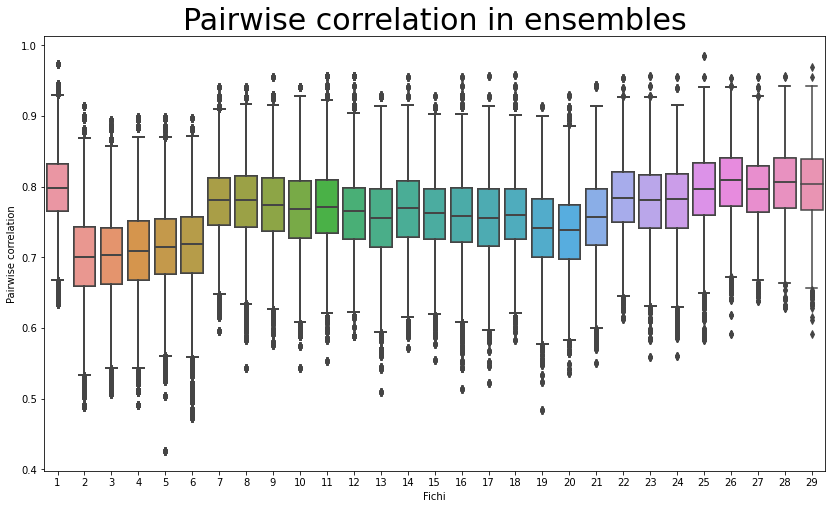

In [63]:
X = breast_cancer.data
y = breast_cancer.target
plt.figure(figsize=(14,8))
cor_res = pd.DataFrame([])
for i in range(1, X.shape[1], 1):
  X_train, X_test, y_train, y_test = train_test_split(X[:,:i], y, random_state=42)
  model = RandomForestClassifier()
  model.fit(X_train, y_train)
  pair_correlations = base_model_pair_correlation(model, X_test)
  tmp = pd.DataFrame(pair_correlations)
  tmp = tmp.melt(value_vars=tmp.columns, value_name="paircor", var_name="model")
  tmp['model'] = i
  cor_res = cor_res.append(tmp)
  
  sns.boxplot(y = cor_res['paircor'], x = cor_res['model'])

  plt.title('Pairwise correlation in ensembles', size = 30)
  plt.xlabel('Fichi', size = 10)
  plt.ylabel('Pairwise correlation', size = 10)

# Задание 5. Ансамблевое обучение (без баллов, плюс в карму)

В данной задаче вам нужно диагностировать сердечное заболевание у людей по [медицинским показателям](https://www.kaggle.com/ronitf/heart-disease-uci).


In [64]:
!gdown  --id 1VFbDK-Ad-hpf0_GGCBzn4thdn9mkQ-Y- -O heart.csv 
heart_dataset = pd.read_csv("/content/heart.csv")

Downloading...
From: https://drive.google.com/uc?id=1VFbDK-Ad-hpf0_GGCBzn4thdn9mkQ-Y-
To: /content/heart.csv
100% 11.3k/11.3k [00:00<00:00, 1.97MB/s]


In [65]:
X = heart_dataset.drop("target", axis=1)
y = heart_dataset['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
287,57,1,1,154,232,0,0,164,0,0.0,2,1,2
282,59,1,2,126,218,1,1,134,0,2.2,1,1,1
197,67,1,0,125,254,1,1,163,0,0.2,1,2,3
158,58,1,1,125,220,0,1,144,0,0.4,1,4,3
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2


Обучите разнообразные классификаторы, приведенные ниже, а также ансамбль `VotingClassifier` из `sklearn.ensemble`, объединяющий эти классификаторы с помощью жесткого или мякого голосования (параметр `voting =` `'hard'` или `'soft'` соответственно). Оцените качество моделей с помощью кросс-валидации на тренировочном наборе, используя функцию `cross_val_score` и метрику `f1`.

In [67]:
rng = np.random.RandomState(42)

dt = DecisionTreeClassifier(random_state=rng, max_depth=10, min_samples_leaf=10)
rf = RandomForestClassifier(n_estimators=50, random_state=rng)
etc = ExtraTreesClassifier(random_state=rng)
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
svc_lin = SVC(kernel='linear', probability=True, random_state=rng)
svc_rbf = SVC(kernel='rbf', probability=True, random_state=rng)
cat = catboost.CatBoostClassifier(verbose=0, random_seed=42)
lgbm = lightgbm.LGBMClassifier(random_state=42)
lgbm_rf = lightgbm.LGBMClassifier(boosting_type="rf", bagging_freq=1, bagging_fraction=0.7, random_state=42)
xgb = xgboost.XGBClassifier(random_state=42)
xgb_rf = xgboost.XGBRFClassifier(random_state=42)
lr = LogisticRegression(solver='liblinear', max_iter=10000)
nb = GaussianNB()

## START YOUR CODE HERE ##

voting_hard = VotingClassifier(estimators=[
          ('dt', dt), ('rf', rf), ('etc', etc), ('knn', knn), ('svc_lin', svc_lin), ('svc_rbf', svc_rbf), ('cat', cat),
          ('lgbm', lgbm), ('lgbm_rf', lgbm_rf), ('xgb', xgb), ('xgb_rf', xgb_rf), ('lr', lr), ('nb', nb)], voting='hard')

voting_hard.fit(X_train, y_train)

voting_soft = VotingClassifier(estimators=[
            ('dt', dt), ('rf', rf), ('etc', etc), ('knn', knn), ('svc_lin', svc_lin), ('svc_rbf', svc_rbf), ('cat', cat),
            ('lgbm', lgbm), ('lgbm_rf', lgbm_rf), ('xgb', xgb), ('xgb_rf', xgb_rf), ('lr', lr), ('nb', nb)], voting='soft')

voting_soft.fit(X_train, y_train)

## END YOUR CODE HERE ##

for model in [dt, rf, cat, etc, knn, svc_lin, svc_rbf, xgb, lgbm, xgb_rf, lgbm_rf, lr, nb, voting_hard, voting_soft]: 
  scores = cross_val_score(model, X_train, y_train, cv=KFold(n_splits=3, shuffle=True, random_state=rng), scoring='f1')
  print(f'{model.__class__.__name__}: {scores.mean()}')

Custom logger is already specified. Specify more than one logger at same time is not thread safe.

DecisionTreeClassifier: 0.7957693229810229
RandomForestClassifier: 0.7775258199977301
CatBoostClassifier: 0.8383007326745985
ExtraTreesClassifier: 0.8322016736650882
KNeighborsClassifier: 0.6182226182226181
SVC: 0.8386009216039275
SVC: 0.7014610456939684
XGBClassifier: 0.8408008259559123
LGBMClassifier: 0.830209411185021
XGBRFClassifier: 0.789126559714795
LGBMClassifier: 0.8294334975369457
LogisticRegression: 0.8262822448868961
GaussianNB: 0.8314176245210728
VotingClassifier: 0.8214210415348936
VotingClassifier: 0.8181039389502702


Вы можете заметить, что ансамбль показывает хорошее, но не лучшее качество предсказания, попробуем его улучшить. Как вы знаете, ансамбли работают лучше, когда модели, входящие в них не сккоррелированы друг с другом. Определите корреляцию предсказаний базовых моделей в ансамбле на тренировочном наборе, и удалите из ансамбля те модели, чьи предсказания будут сильнее коррелировать с остальными. Можете модифицировать функцию `base_model_pair_correlation` из предыдущего задания. 


In [68]:
#...


Создайте новый ансамбль, на исправленном наборе моделей и оцените его качество с помощью кросс-валидации на тренировочном наборе, используя функцию `cross_val_score` и метрику `f1`.

In [69]:
## START CODE HERE ##

voting_hard_2 = VotingClassifier(estimators=[
          ('cat', cat), ('xgb', xgb), ('lr', lr), ('nb', nb)], voting='hard')

voting_hard_2.fit(X_train, y_train)

voting_soft_2 = VotingClassifier(estimators=[
            ('cat', cat), ('xgb', xgb), ('lr', lr), ('nb', nb)], voting='soft')

voting_soft_2.fit(X_train, y_train)
## END CODE HERE ##

for model in [voting_hard_2, voting_soft_2]:
  scores = cross_val_score(model, X_train, y_train, cv=KFold(n_splits=3, shuffle=True, random_state=rng), scoring='f1')
  print(f'{model.__class__.__name__}: {scores.mean()}')

VotingClassifier: 0.8148123668943232
VotingClassifier: 0.8528405750627973


Обучите все получившиеся модели на тренировочном наборе и испытайте их качество на тестовом наборе. Получилось ли у улучшенных версий ансамблевого классификатора превзойти базовые модели, входящие в него и свои предыдущие версии? 

In [70]:
from sklearn.metrics import f1_score

In [72]:
voting_hard.fit(X_train, y_train)
voting_soft.fit(X_train, y_train)

voting_hard_2.fit(X_train, y_train)
voting_soft_2.fit(X_train, y_train)


for model in [dt, rf, cat, etc, knn, svc_lin, svc_rbf, xgb, lgbm, xgb_rf, lgbm_rf, lr, nb, voting_hard, voting_soft, voting_hard_2, voting_soft_2]: 
  sc = f1_score(y_test, model.predict(X_test))
  print(f'{model.__class__.__name__}: {sc}')

DecisionTreeClassifier: 0.8333333333333333
RandomForestClassifier: 0.8705882352941177
CatBoostClassifier: 0.8333333333333333
ExtraTreesClassifier: 0.8433734939759037
KNeighborsClassifier: 0.7380952380952381
SVC: 0.8809523809523809
SVC: 0.7628865979381443
XGBClassifier: 0.8536585365853658
LGBMClassifier: 0.8
XGBRFClassifier: 0.8333333333333333
LGBMClassifier: 0.8735632183908046
LogisticRegression: 0.8809523809523809
GaussianNB: 0.888888888888889
VotingClassifier: 0.8470588235294119
VotingClassifier: 0.8470588235294119
VotingClassifier: 0.8641975308641976
VotingClassifier: 0.8915662650602411
